In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#Minimum, maximum and optimal temperature
T = np.arange(14, 38, 0.5)
T_min = 20      #degC
T_max = 31      #degC
T_opt = 27.5    #degC
T_x = np.full_like(T,T_min)
T_x[T > T_opt] = T_max
growth_factor_T = np.exp(-2 * ((T - T_opt) /(T_x - T_opt))**2 )

#Nitrogen half saturation constant
N = np.arange(0.00001, 0.1, 0.00001)
k_N_values = [0.000129, 0.001, 0.01]  # mmol/m3
growth_factor_N = {}
for k_N in k_N_values:
    growth_factor_N[k_N] = N / (N + k_N)

#Optimal salinity
S = np.arange(20, 40, 0.05)
S_opt = 36 #psu
growth_factor_S = np.exp(-0.02 * (S_opt - S)**2)

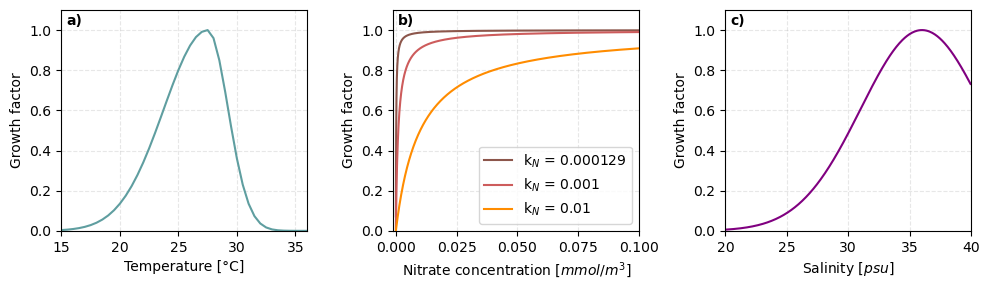

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3))

#Temperature
ax[0].plot(T, growth_factor_T, label='Jouanno et al. (2025)', c = 'cadetblue')
ax[0].set_xlabel('Temperature [°C]')
ax[0].set_xlim(15,36)

#Nitrogen concentration
colors = {0.000129: 'tab:brown', 0.001: 'indianred', 0.01: 'darkorange'}
for k_N in k_N_values:
    ax[1].plot(N, growth_factor_N[k_N], label=f'k$_N$ = {k_N}', color=colors[k_N])
ax[1].set_xlabel('Nitrate concentration [$mmol / m^3$]')
ax[1].set_xlim(-0.001,0.1)
ax[1].legend(loc='lower right')

#Salinity concentration
ax[2].plot(S, growth_factor_S, label = ' Jouanno et al. (2025)', color='purple')
ax[2].set_xlabel('Salinity [$psu$]')
ax[2].set_xlim(20,40)

for i, label in enumerate(['a)', 'b)', 'c)']):
    ax[i].grid(alpha=0.3, linestyle='--')
    ax[i].set_ylabel('Growth factor')
    ax[i].set_ylim([0, 1.1])
    ax[i].text(0.02, 0.98, label, transform=ax[i].transAxes,
               fontsize=10, fontweight='bold', va='top')

plt.tight_layout()
plt.savefig("Figures/FigureA2.pdf", format="pdf", bbox_inches="tight")
plt.show()